<a href="https://colab.research.google.com/github/daveveed/Geo-Data-Science/blob/main/Data_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np, geopandas as gpd, os, matplotlib.pyplot as plt, requests

In [3]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.makedirs(data_folder)

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [8]:
def download(url):

  filename = os.path.join(data_folder, os.path.basename(url))

  if not os.path.exists(filename):
    response = requests.get(url, allow_redirects=True)

    with open(filename, 'wb') as f:
      f.write(response.content)
  print('downloaded: ', filename)



In [9]:
data_url = 'https://raw.githubusercontent.com/daveveed/Geo-Data-Science/main/Data/Temp/helsinki_region_travel_times_to_railway_station.gpkg'
download(data_url)

downloaded:  data/helsinki_region_travel_times_to_railway_station.gpkg


In [10]:
data_path = os.path.join(data_folder, 'helsinki_region_travel_times_to_railway_station.gpkg')

grid = gpd.read_file(data_path)
grid.head()

,car_m_d,car_m_t,car_r_d,car_r_t,from_id,pt_m_d,pt_m_t,pt_m_tt,pt_r_d,pt_r_t,pt_r_tt,to_id,walk_d,walk_t,geometry
0,32297,43,32260,48,5785640,32616,116,147,32616,108,139,5975375,32164,459,"POLYGON ((382000 6697750, 381750 6697750, 3817..."
1,32508,43,32471,49,5785641,32822,119,145,32822,111,133,5975375,29547,422,"POLYGON ((382250 6697750, 382000 6697750, 3820..."
2,30133,50,31872,56,5785642,32940,121,146,32940,113,133,5975375,29626,423,"POLYGON ((382500 6697750, 382250 6697750, 3822..."
3,32690,54,34429,60,5785643,33233,125,150,33233,117,144,5975375,29919,427,"POLYGON ((382750 6697750, 382500 6697750, 3825..."
4,31872,42,31834,48,5787544,32127,109,126,32127,101,121,5975375,31674,452,"POLYGON ((381250 6697500, 381000 6697500, 3810..."


We will use column 'pt_r_t' which contains information about travel time in minutes to the central railway station by public transportation in rush hour traffic. Missing data are presented with value -1. Let’s set the missing values as NaN to exclude no data from further analysis:

In [11]:
grid = grid.replace(-1, np.nan)

<Axes: ylabel='Frequency'>

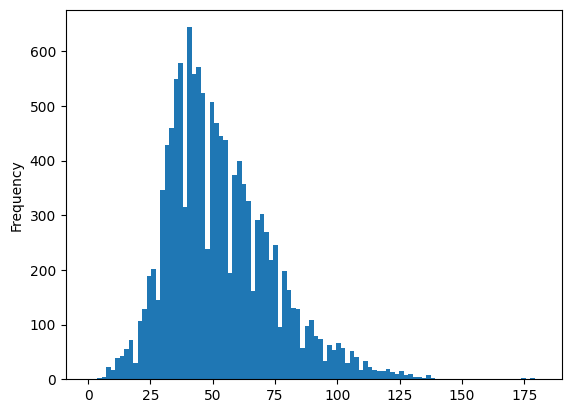

In [12]:
# creating a data series without NaN values
travel_times = grid.loc[grid['pt_r_t'].notnull(), 'pt_r_t']

travel_times.plot.hist(bins=100)

In [13]:
travel_times.describe()

,pt_r_t
count,13020.000000
mean,53.124654
std,21.295944
min,0.000000
25%,38.000000
50%,49.000000
75%,65.000000
max,181.000000


The maximum travel time to the central railway station by public transport (including time for walking) is 181 minutes, i.e. over three hours. Most of the travel times range between 38 and 65 minutes with an average travel time of 53 minutes. Looking at the histogram, we can tell than only a handful of grid squares have more than two hour travel times to the central railway station. These grid squares are most likely located in rather inaccessible places in terms of public transport accessibility.

Let’s have a closer look at how these mapclassify classifiers work and try out different classification schemes for visualizing the public transport traveltimes.

### Natural breaks

In [15]:
import mapclassify
print(mapclassify.NaturalBreaks(travel_times))

NaturalBreaks

    Interval       Count
------------------------
[  0.00,  34.00] |  2293
( 34.00,  50.00] |  4488
( 50.00,  68.00] |  3453
( 68.00,  92.00] |  2094
( 92.00, 181.00] |   692


In [16]:
mapclassify.NaturalBreaks(y=travel_times, k = 10)

NaturalBreaks

    Interval       Count
------------------------
[  0.00,  22.00] |   451
( 22.00,  33.00] |  1602
( 33.00,  41.00] |  2326
( 41.00,  48.00] |  1894
( 48.00,  56.00] |  1859
( 56.00,  65.00] |  1649
( 65.00,  75.00] |  1380
( 75.00,  89.00] |  1036
( 89.00, 109.00] |   603
(109.00, 181.00] |   220

In [17]:
# extracting the thresholds
mapclassify.NaturalBreaks(y= travel_times, k = 10).bins

array([ 23.,  34.,  43.,  53.,  62.,  71.,  82.,  96., 115., 181.])

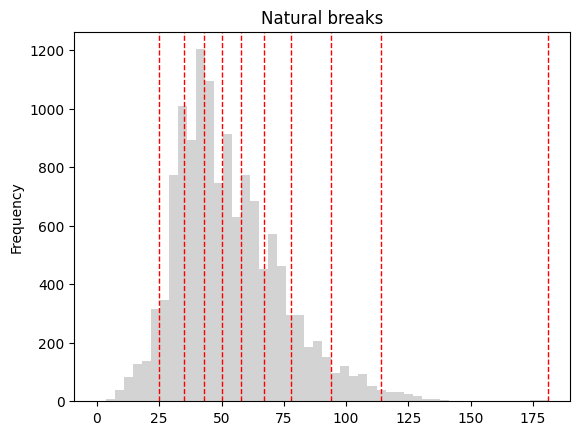

In [21]:
# exploring the histogram

classifier = mapclassify.NaturalBreaks(y= travel_times, k = 10)

#plot
ax = grid['pt_r_t'].plot(kind='hist', bins=50, color='lightgrey',
                    title='Natural breaks')

# Plot vertical lines for each natural break bin
for bin_val in classifier.bins:
    ax.axvline(bin_val, color='red', linestyle='dashed', linewidth=1)

In [23]:
# We can apply the classifier on our data and store the result in a new column.

# Classify the data
grid["pt_r_t_nb"] = grid[["pt_r_t"]].apply(classifier)
grid.head()

,car_m_d,car_m_t,car_r_d,car_r_t,from_id,pt_m_d,pt_m_t,pt_m_tt,pt_r_d,pt_r_t,pt_r_tt,to_id,walk_d,walk_t,geometry,pt_r_t_nb
0,32297.0,43.0,32260.0,48.0,5785640,32616.0,116.0,147.0,32616.0,108.0,139.0,5975375.0,32164.0,459.0,"POLYGON ((382000 6697750, 381750 6697750, 3817...",8
1,32508.0,43.0,32471.0,49.0,5785641,32822.0,119.0,145.0,32822.0,111.0,133.0,5975375.0,29547.0,422.0,"POLYGON ((382250 6697750, 382000 6697750, 3820...",8
2,30133.0,50.0,31872.0,56.0,5785642,32940.0,121.0,146.0,32940.0,113.0,133.0,5975375.0,29626.0,423.0,"POLYGON ((382500 6697750, 382250 6697750, 3822...",8
3,32690.0,54.0,34429.0,60.0,5785643,33233.0,125.0,150.0,33233.0,117.0,144.0,5975375.0,29919.0,427.0,"POLYGON ((382750 6697750, 382500 6697750, 3825...",9
4,31872.0,42.0,31834.0,48.0,5787544,32127.0,109.0,126.0,32127.0,101.0,121.0,5975375.0,31674.0,452.0,"POLYGON ((381250 6697500, 381000 6697500, 3810...",8


<Axes: >

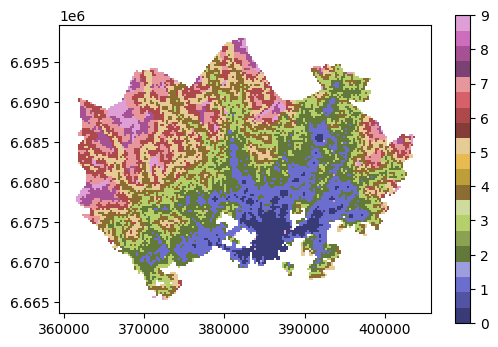

In [24]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(6,4)

grid.plot(ax=ax, column='pt_r_t_nb', cmap='tab20b', legend=True)

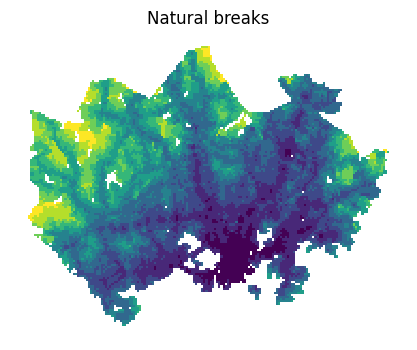

In [28]:
fig2, ax2 = plt.subplots(1,1)
fig2.set_size_inches(6,4)

grid.plot(ax=ax2, column='pt_r_t', scheme='natural_breaks', k = 10)

plt.axis('off')
plt.title('Natural breaks')
plt.show()

### Quantiles

In [29]:
mapclassify.Quantiles(y=travel_times, k=10)

Quantiles

    Interval       Count
------------------------
[  0.00,  30.00] |  1406
( 30.00,  36.00] |  1436
( 36.00,  40.00] |  1242
( 40.00,  44.00] |  1135
( 44.00,  49.00] |  1319
( 49.00,  55.00] |  1392
( 55.00,  62.00] |  1342
( 62.00,  70.00] |  1265
( 70.00,  81.00] |  1190
( 81.00, 181.00] |  1293

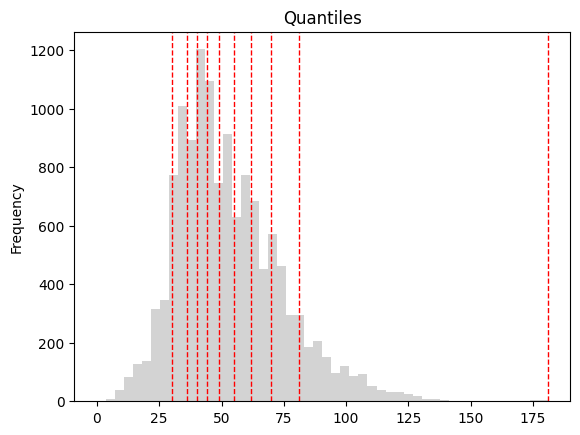

In [31]:
classifier = mapclassify.Quantiles(y= travel_times, k = 10)

#plot
ax = grid['pt_r_t'].plot(kind='hist', bins=50, color='lightgrey',
                    title='Quantiles')
for break_point in classifier.bins:
    ax.axvline(break_point, color='red', linestyle='dashed', linewidth=1)

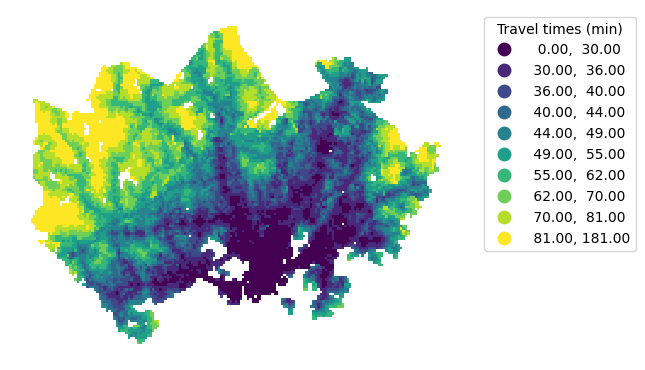

In [32]:
# Plot the data using quantiles
ax = grid.plot(
    figsize=(6, 4),
    column="pt_r_t",
    linewidth=0,
    scheme="quantiles",
    k=10,
    legend=True,
    legend_kwds={"title": "Travel times (min)", "bbox_to_anchor": (1.4, 1)},
)

# Set the x and y axis off and adjust padding around the subplot
plt.axis("off")
plt.tight_layout()

### custom map classification

In [33]:
break_values = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
classifier = mapclassify.UserDefined(y=travel_times, bins=break_values)
classifier


UserDefined

    Interval       Count
------------------------
[  0.00,   0.00] |     1
(  0.00,  10.00] |    48
( 10.00,  20.00] |   286
( 20.00,  30.00] |  1071
( 30.00,  40.00] |  2678
( 40.00,  50.00] |  2697
( 50.00,  60.00] |  2125
( 60.00,  70.00] |  1631
( 70.00,  80.00] |  1109
( 80.00,  90.00] |   603
( 90.00, 181.00] |   771

In [35]:
classifier.bins

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 181.])

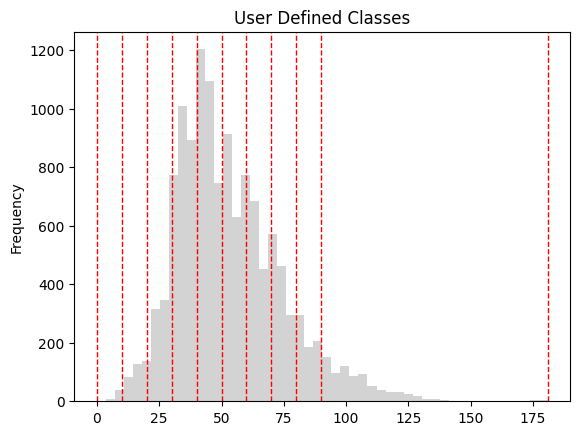

In [34]:
ax = grid['pt_r_t'].plot.hist(bins=50, title= 'User Defined Classes',
                              color= 'lightgrey')

for break_point in classifier.bins:
    ax.axvline(break_point, color='red', linestyle='dashed', linewidth=1)

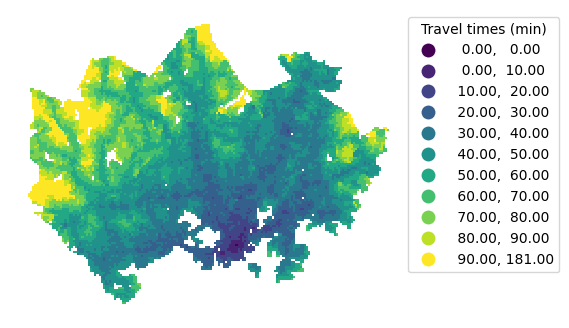

In [39]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(6,4)

grid.plot(ax=ax, column='pt_r_t', scheme='user_defined',
          classification_kwds={'bins': break_values},
          legend=True,
          legend_kwds={"title": "Travel times (min)", "bbox_to_anchor": (1.4, 1)})

plt.axis('off')
plt.show()

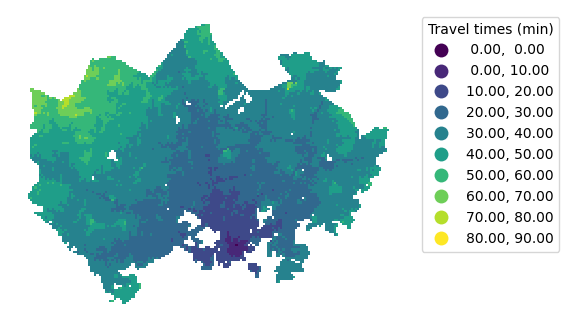

In [40]:
# plotting for travel times with cars car_r_t

fig,ax = plt.subplots(1,1)
fig.set_size_inches(6,4)

grid.plot(ax=ax, column='car_r_t', scheme= 'UserDefined',
          classification_kwds={'bins': break_values},
          legend=True, legend_kwds={"title": "Travel times (min)", "bbox_to_anchor": (1.4, 1)})

plt.axis('off')
plt.show()

### Rule based classification

Sometimes our analysis task benefits from combining multiple criteria for classifying data. For example, we might want to find out locations that are outside the city center within a reasonable public transport travel time. Such a selection could help us classify the statistical grid squares based on the potential for finding apartments with good public transport connections while avoiding the most expensive areas in the city center.

To implement this, we can use conditional statements to find grid squares where public transport travel time (column pt_r_tt) is less than a selected threshold value in minutes, and where walking distance (walk_d) is more than a selected threshold value in meters. Each rule will give a binary result (True/False) and we can further combine these rules to find those locations that meet both requirements.

In [41]:
# thresholds
pt_maximum = 30
walk_mimumum = 2500

grid['pt_r_tt'] < pt_maximum

,pt_r_tt
0,False
1,False
2,False
3,False
4,False
...,...
13226,False
13227,False
13228,False
13229,False


In [42]:
grid['rule1'] = (grid['pt_r_t'] < pt_maximum) & (grid['walk_d'] > walk_mimumum)

In [43]:
grid.loc[grid['rule1'] == True].explore()